In [3]:
import numpy as np
import pandas as pd
import statistics

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)


In [4]:
data = pd.read_csv("../data/data.csv", index_col=0)
print(data)

      country time_of_day        lat       long       road_type  \
8459       SE         day  55.604209  13.028574            city   
63960      DE         day  50.936889   6.908079  arterial-urban   
71801      IT         day  41.987014  12.496538         highway   
85589      IT       night  41.794853  12.522880         highway   
90649      DE         day  49.182153   9.414737         highway   
...       ...         ...        ...        ...             ...   
74962      PL         day  54.378439  18.605984  arterial-urban   
90673      PL         day  50.253217  19.823732   smaller-rural   
24373      DE         day  50.931399   6.953686            city   
41597      SE         day  55.608149  13.003458            city   
40353      IT       night  41.918667  12.383545            city   

      road_condition            weather  solar_angle_elevation  month  hour  \
8459          normal             cloudy              36.560248      5    14   
63960         normal               ra

In [5]:
all_columns = data.columns    

print(f"Number of rows: {data.shape[0]}")
print(f"Columns: {all_columns}")
print(f"Number of columns: {len(all_columns)}")

Number of rows: 9999
Columns: Index(['country', 'time_of_day', 'lat', 'long', 'road_type', 'road_condition',
       'weather', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'sunshine_duration',
       'wind_speed_10m', 'weather_code', 'laplacian', 'quality', 'brightness',
       'noisiness', 'sharpness', 'contrast', 'complexity', 'conf', 'iou',
       'lrp', 'pq'],
      dtype='object')
Number of columns: 31


In [6]:
numeric_columns = ['lat', 'long', 'solar_angle_elevation', 'month', 'hour', 'temperature_2m',
       'relative_humidity_2m', 'rain', 'snowfall',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'sunshine_duration', 'wind_speed_10m', 'conf',  'laplacian', 'quality', 'brightness', 'noisiness', 'sharpness', 'contrast', 'complexity', 
       'iou', 'lrp', 'pq']
#'precipitation',

categorical_columns = ['time_of_day', 'country', 'road_type', 'road_condition',
       'weather', 'weather_code']

assert len(all_columns) == (len(categorical_columns) + len(numeric_columns)), "Columns not match"


# EDA

## Categorical Variables

In [7]:
print(f"Number of categorical features: {len(categorical_columns)}")
for col in categorical_columns:
    print("-" * 10)
    print(f"Column: {col}")
    print(f"Unique values: {data[col].nunique()}")
    print(f"Most common: {data[col].mode().iloc[0] if not data[col].mode().empty else 'N/A'}")
    print(f"Missing values: {data[col].isnull().sum()}")

Number of categorical features: 6
----------
Column: time_of_day
Unique values: 3
Most common: day
Missing values: 0
----------
Column: country
Unique values: 9
Most common: DE
Missing values: 0
----------
Column: road_type
Unique values: 5
Most common: city
Missing values: 0
----------
Column: road_condition
Unique values: 3
Most common: normal
Missing values: 0
----------
Column: weather
Unique values: 9
Most common: partly-cloudy-day
Missing values: 0
----------
Column: weather_code
Unique values: 11
Most common: 3.0
Missing values: 0


Distribution

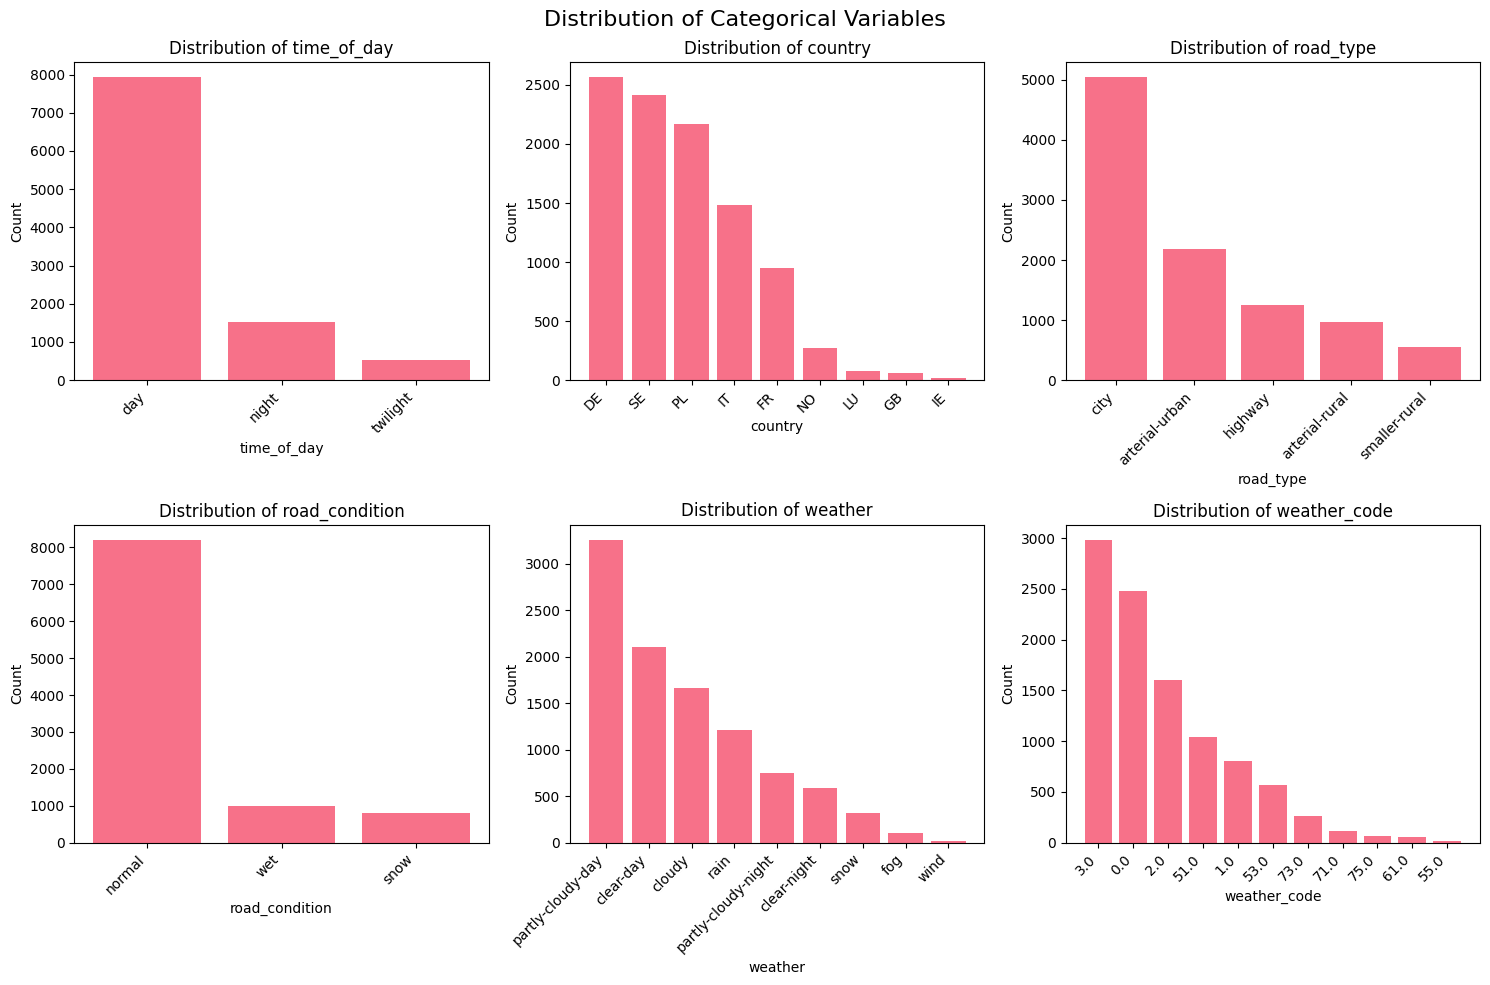

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    value_counts = data[column].value_counts()
    axes[i].bar(range(len(value_counts)), value_counts.values)
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')


plt.tight_layout()
plt.savefig("./plots/categorical_distributions.png")
plt.show()

Correlation - Using Pearson and labels encoded

In [9]:

encoded_data = data[categorical_columns].copy()
label_encoders = {}
for column in categorical_columns:
    le = LabelEncoder()
    encoded_data[column] = encoded_data[column].fillna('Unknown')
    encoded_data[column] = le.fit_transform(encoded_data[column])
    label_encoders[column] = le

pearson_corr = encoded_data.corr()
print(pearson_corr.round(3))

                time_of_day  country  road_type  road_condition  weather  \
time_of_day           1.000   -0.179      0.078           0.014    0.169   
country              -0.179    1.000     -0.030           0.161    0.001   
road_type             0.078   -0.030      1.000          -0.073   -0.075   
road_condition        0.014    0.161     -0.073           1.000    0.335   
weather               0.169    0.001     -0.075           0.335    1.000   
weather_code         -0.067    0.181     -0.097           0.438    0.566   

                weather_code  
time_of_day           -0.067  
country                0.181  
road_type             -0.097  
road_condition         0.438  
weather                0.566  
weather_code           1.000  


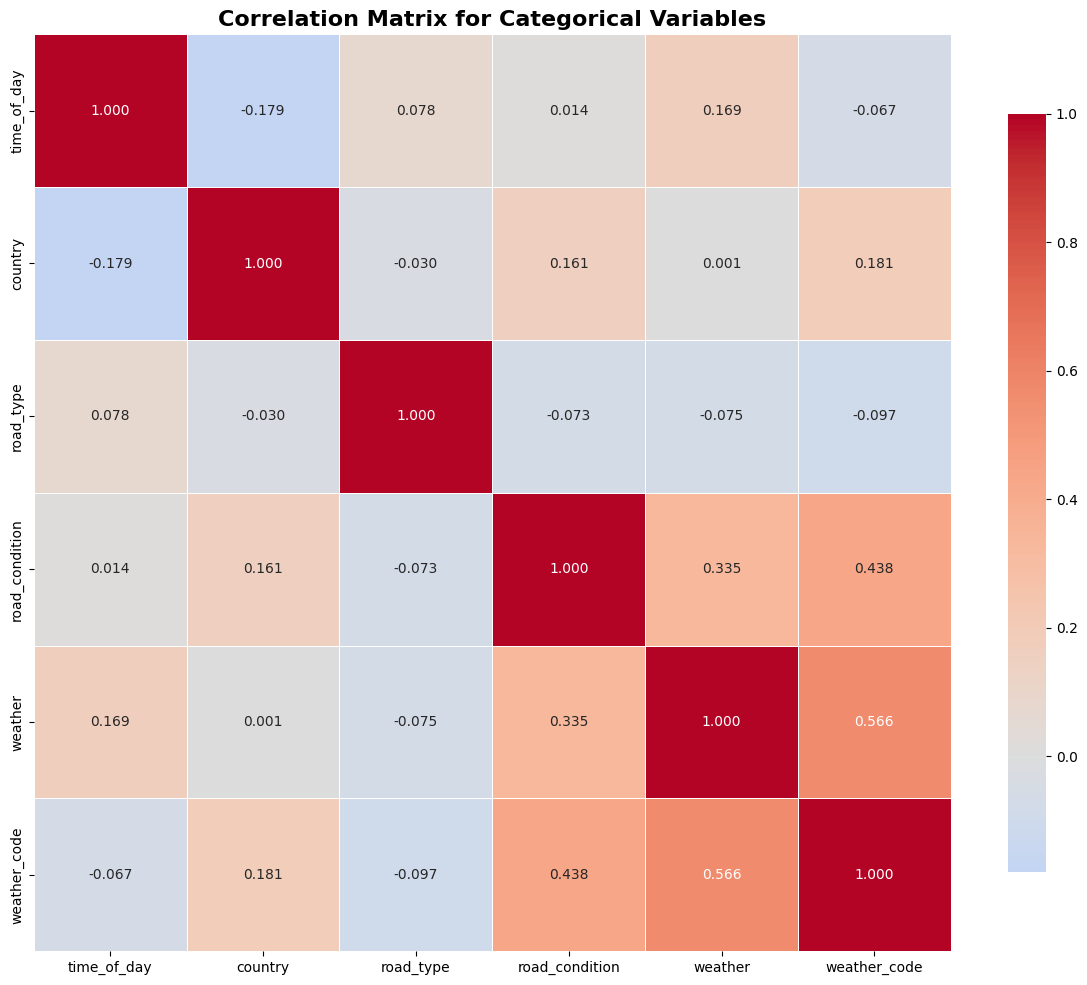

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.3f', cbar_kws={"shrink": .8})
plt.title("Correlation Matrix for Categorical Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("./plots/categorical_correlation_matrix.png")
plt.show()

## Numerical Variables 

In [11]:
print(f"Number of numerical features: {len(numeric_columns)}")
for col in numeric_columns:
    if col == 'coords':
        continue
    clean_data = data[col].dropna()
    print(f"\n{col.upper()}:")
    print(f"  Count: {len(clean_data)}")
    print(f"  Missing values: {data[col].isnull().sum()}")
    print(f"  Mean: {clean_data.mean():.3f}")
    print(f"  Median: {clean_data.median():.3f}")
    print(f"  Std: {clean_data.std():.3f}")
    print(f"  Min: {clean_data.min():.3f}")
    print(f"  Max: {clean_data.max():.3f}")
    print(f"  Range: {clean_data.max() - clean_data.min():.3f}")
    

Number of numerical features: 25

LAT:
  Count: 9999
  Missing values: 0
  Mean: 52.085
  Median: 52.202
  Std: 6.099
  Min: 41.794
  Max: 68.445
  Range: 26.651

LONG:
  Count: 9999
  Missing values: 0
  Mean: 12.597
  Median: 12.584
  Std: 5.456
  Min: -8.170
  Max: 23.491
  Range: 31.661

SOLAR_ANGLE_ELEVATION:
  Count: 9999
  Missing values: 0
  Mean: 20.180
  Median: 17.451
  Std: 24.133
  Min: -47.484
  Max: 64.865
  Range: 112.349

MONTH:
  Count: 9999
  Missing values: 0
  Mean: 6.122
  Median: 5.000
  Std: 3.244
  Min: 1.000
  Max: 12.000
  Range: 11.000

HOUR:
  Count: 9999
  Missing values: 0
  Mean: 12.548
  Median: 12.000
  Std: 4.035
  Min: 0.000
  Max: 22.000
  Range: 22.000

TEMPERATURE_2M:
  Count: 9999
  Missing values: 0
  Mean: 12.124
  Median: 11.419
  Std: 9.372
  Min: -19.403
  Max: 35.270
  Range: 54.673

RELATIVE_HUMIDITY_2M:
  Count: 9999
  Missing values: 0
  Mean: 71.201
  Median: 72.966
  Std: 15.848
  Min: 22.922
  Max: 100.000
  Range: 77.078

RAIN:
  Cou

Distribution

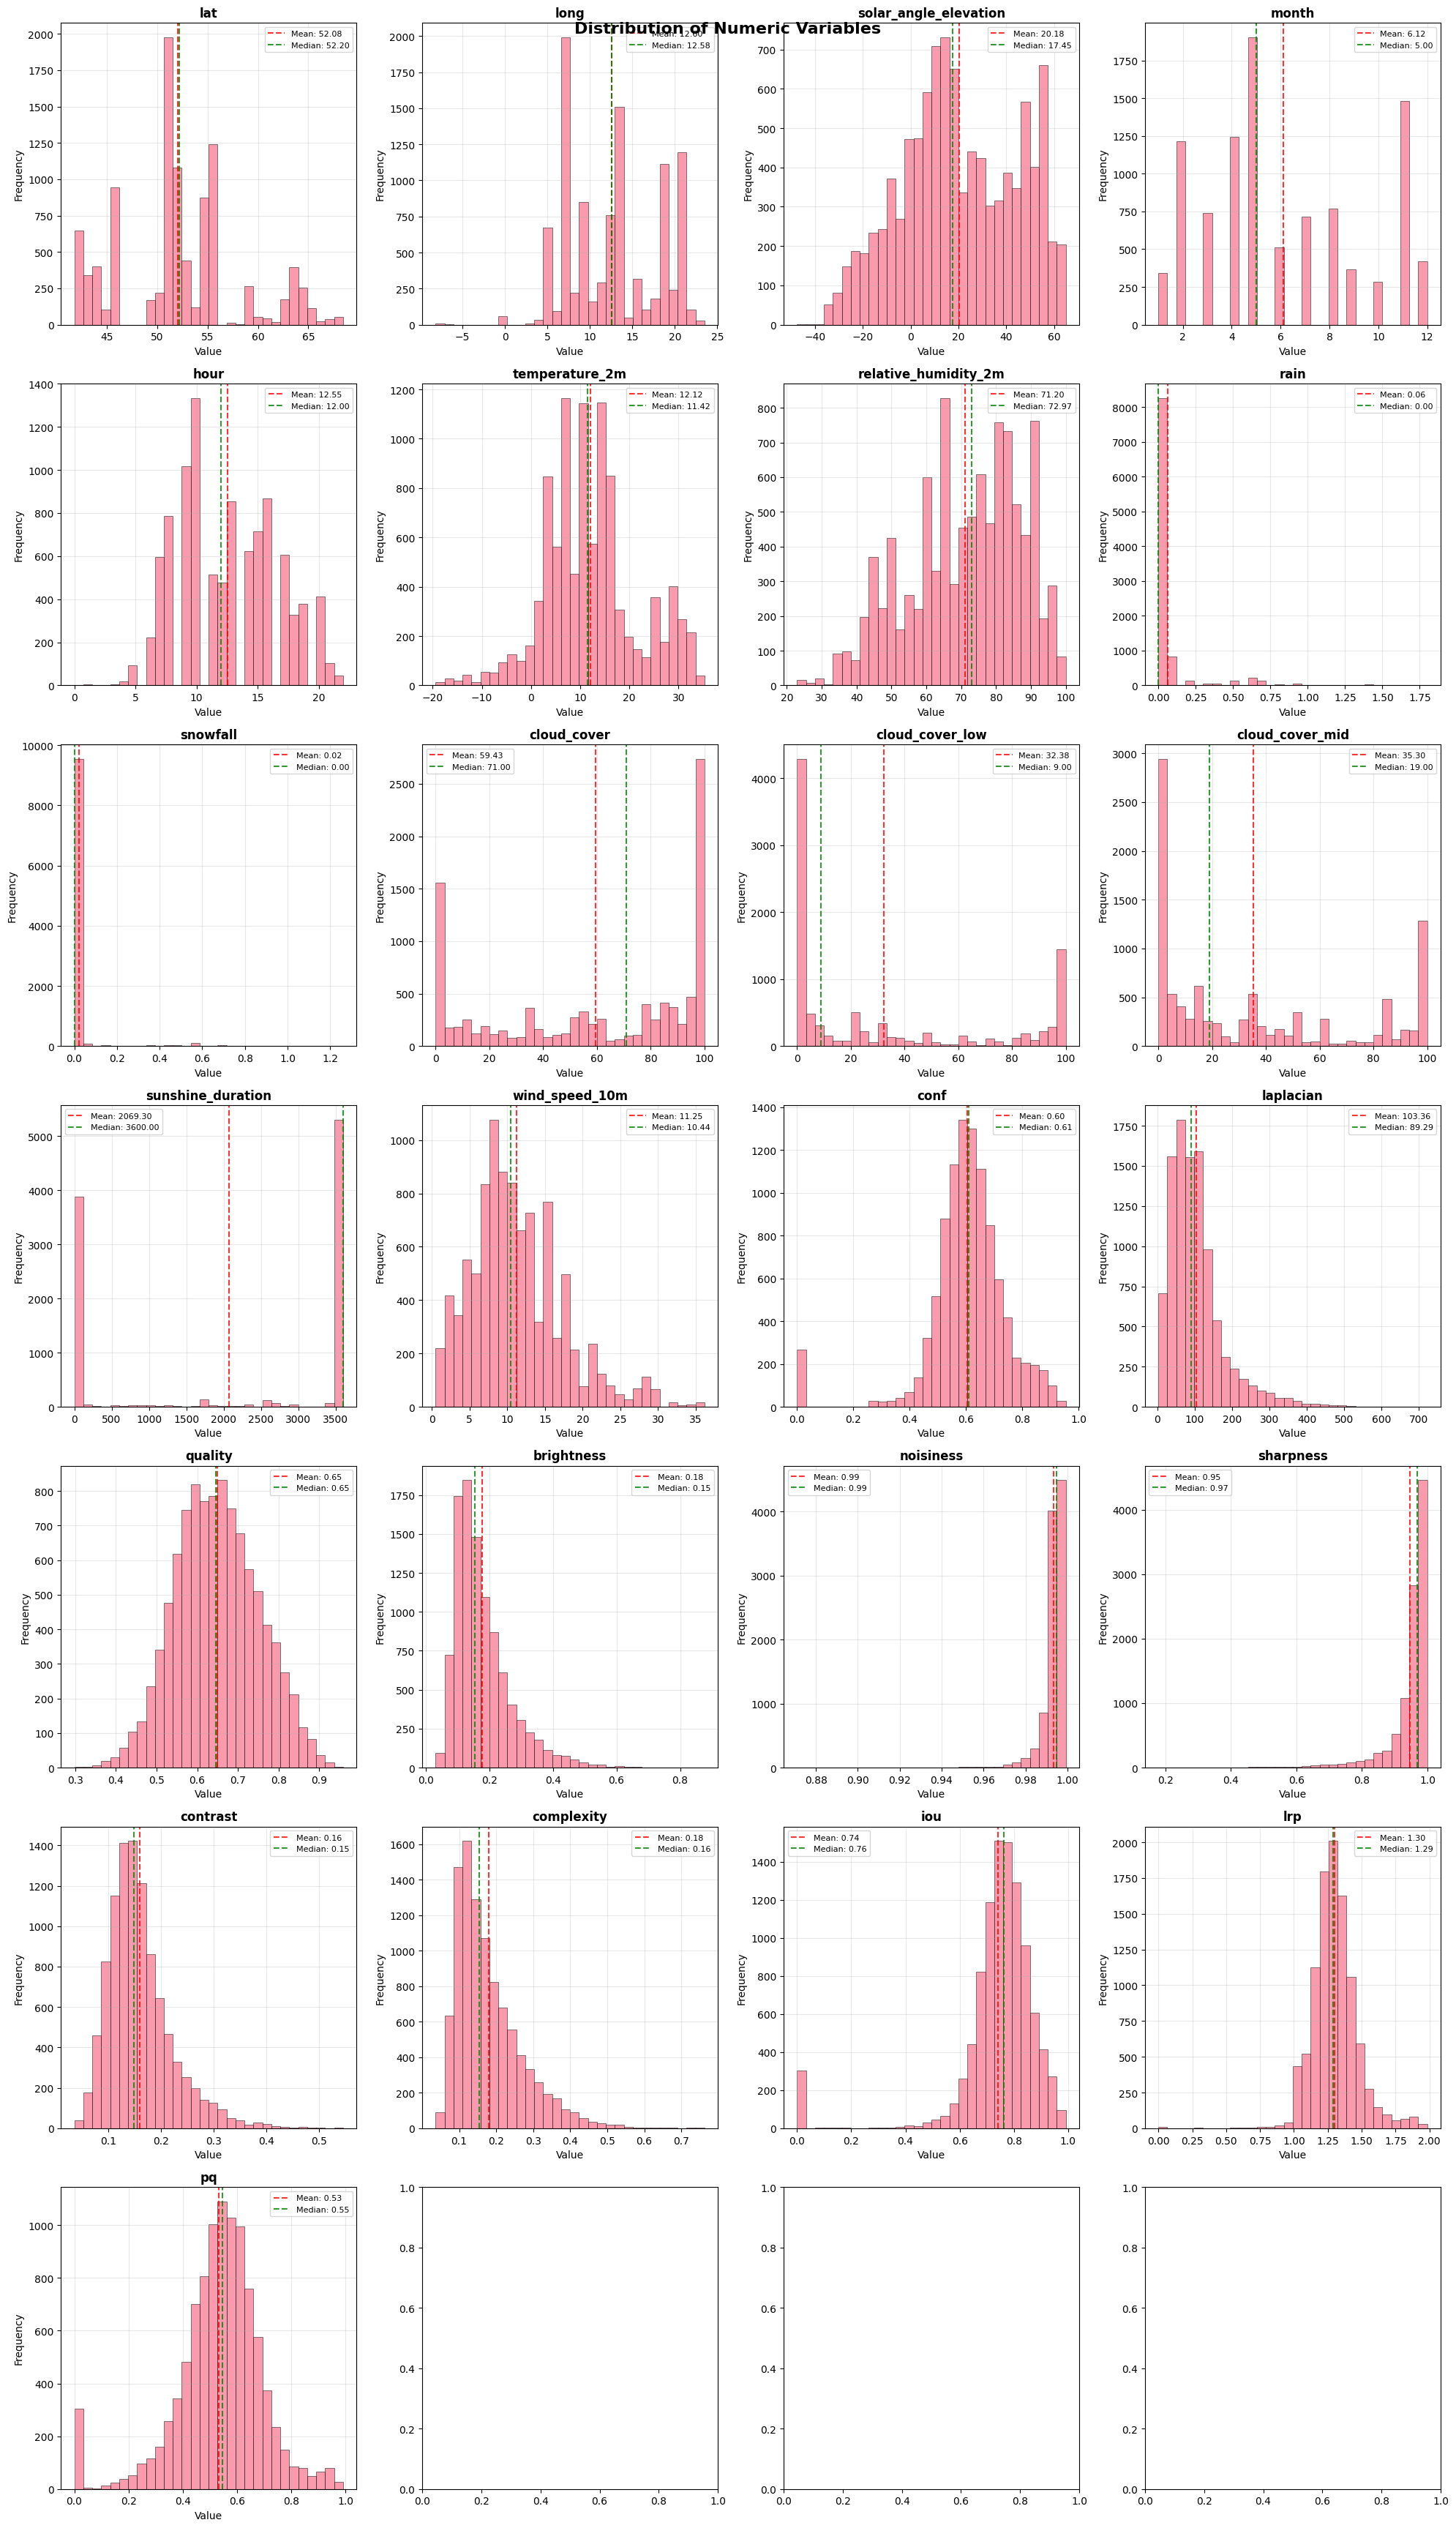

In [12]:
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Distribution of Numeric Variables', fontsize=16, fontweight='bold')
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    axes[i].hist(clean_data, bins=30, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("./plots/numeric_distributions.png")
plt.show()

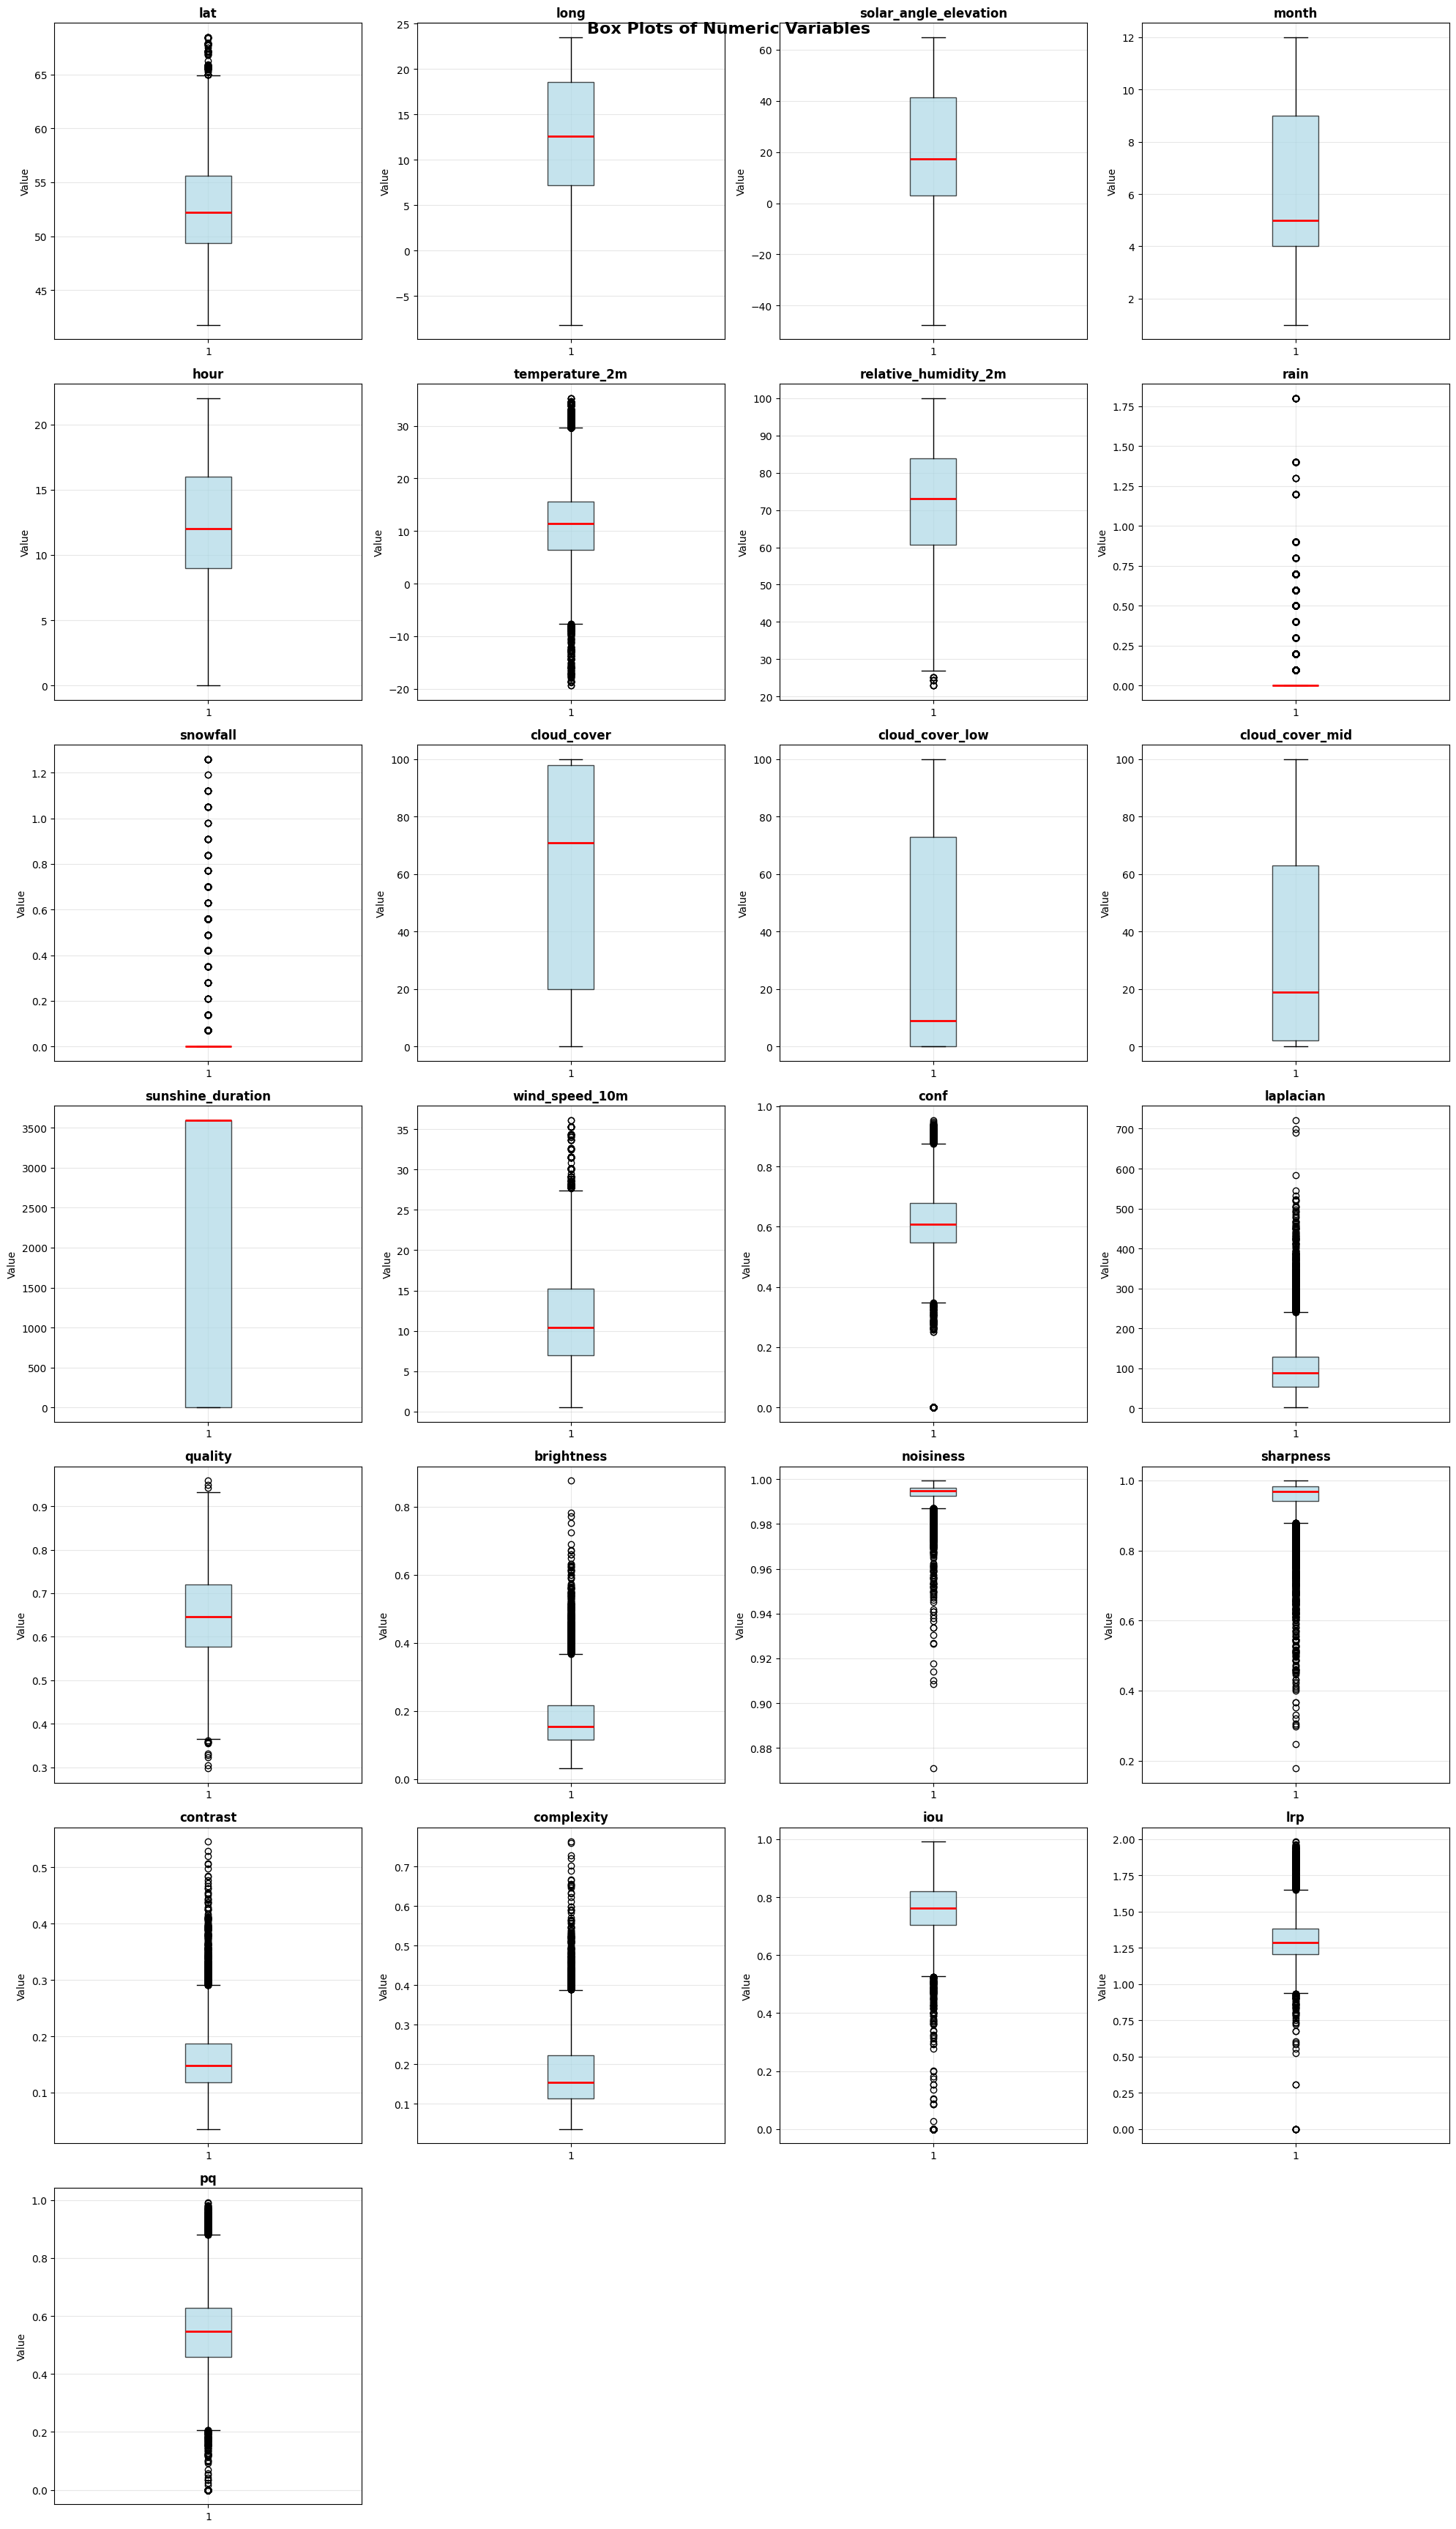

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Box Plots of Numeric Variables', fontsize=16, fontweight='bold')

axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for i, column in enumerate(numeric_columns):
    if column == 'coords':
        continue
    clean_data = data[column].dropna()
    
    # Create box plot
    axes[i].boxplot(clean_data, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{column}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

for i in range(len(numeric_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


Correlation

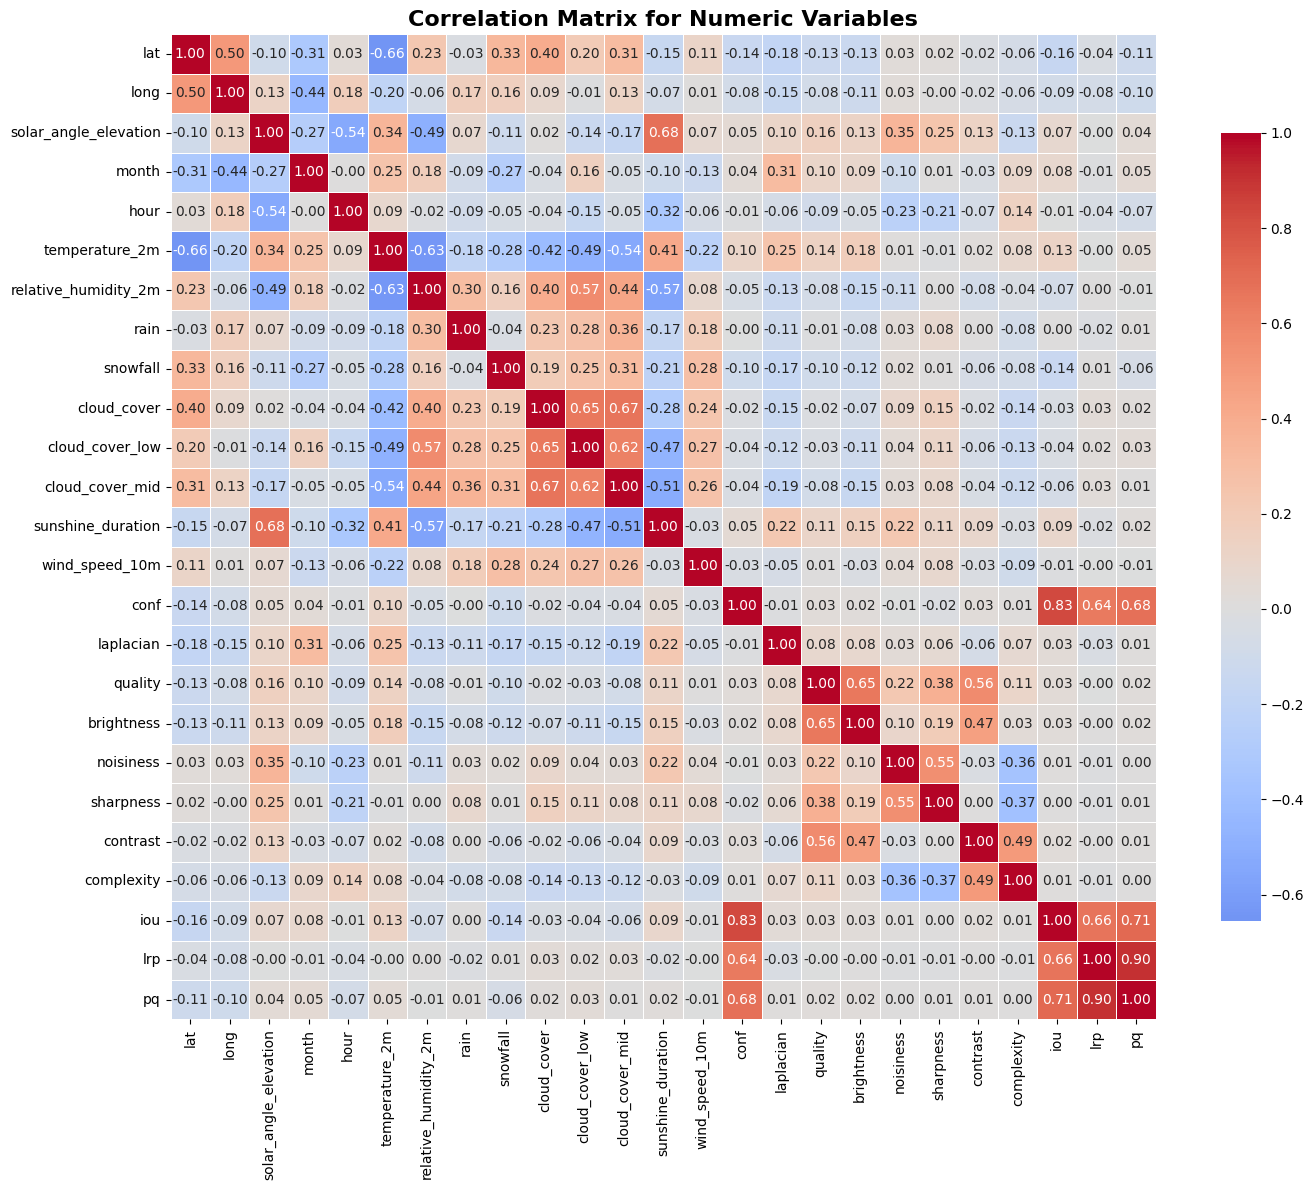

In [14]:
numeric_data = data[numeric_columns].select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr('pearson')

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix for Numeric Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("./plots/numeric_correlation_matrix.png")
plt.show()

## Bivariate Correlation

Bivariate correlations between all these features and against the pass/fail result (success rate) for an instance

### Categorical Var

Use Etta-square for correlation between varaibles and IoU.
It measures the proportion of variance associated with each main effect and interaction effect in an ANOVA model.

In [15]:
def compute_cat_correlations(data, categorical_columns, target_column='iou'):
    categorical_correlations = []

    for col in categorical_columns:
        categories = data[col].unique()
        groups = [data[data[col] == cat][target_column].values for cat in categories]
        groups = [group for group in groups if len(group) > 0]  
        
        if len(groups) >= 2:
            overall_mean = data[target_column].mean()
            ssb = sum(len(group) * (np.mean(group) - overall_mean)**2 for group in groups)
            sst = sum((data[target_column] - overall_mean)**2)
            eta_squared = ssb / sst if sst != 0 else 0
            categorical_correlations.append({'col': col,'Eta_Squared': eta_squared,})

    categorical_corr_df = pd.DataFrame(categorical_correlations)
    categorical_corr_df = categorical_corr_df.sort_values('Eta_Squared', ascending=False)
    return categorical_corr_df

In [16]:
categorical_iou_corr_df = compute_cat_correlations(data, categorical_columns, target_column='iou')
categorical_pq_corr_df = compute_cat_correlations(data, categorical_columns, target_column='pq')
categorical_lrp_corr_df = compute_cat_correlations(data, categorical_columns, target_column='lrp')

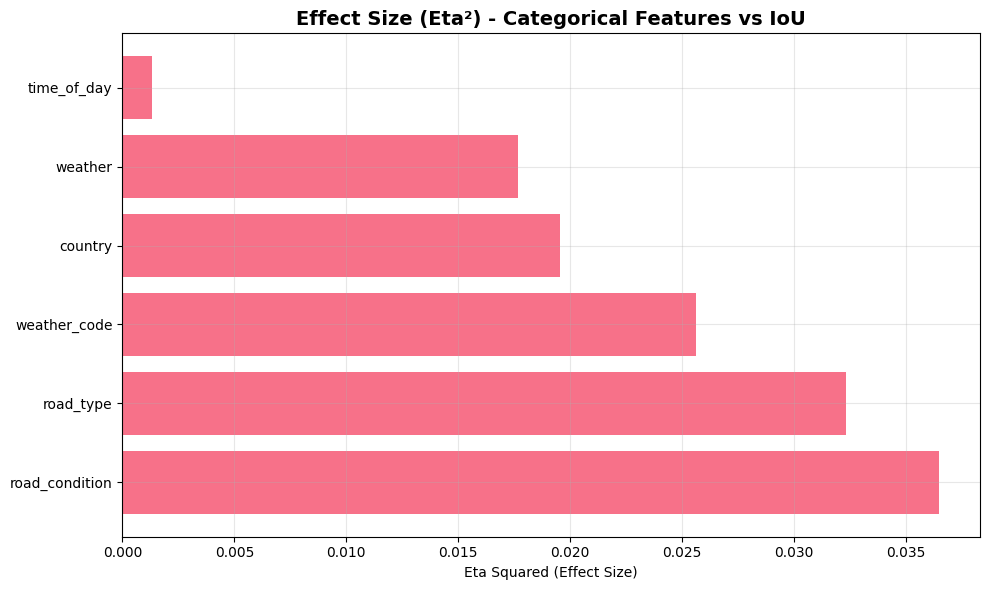

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_iou_corr_df['col'], categorical_iou_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs IoU', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/categorical_iou_effect_size.png")
plt.show()

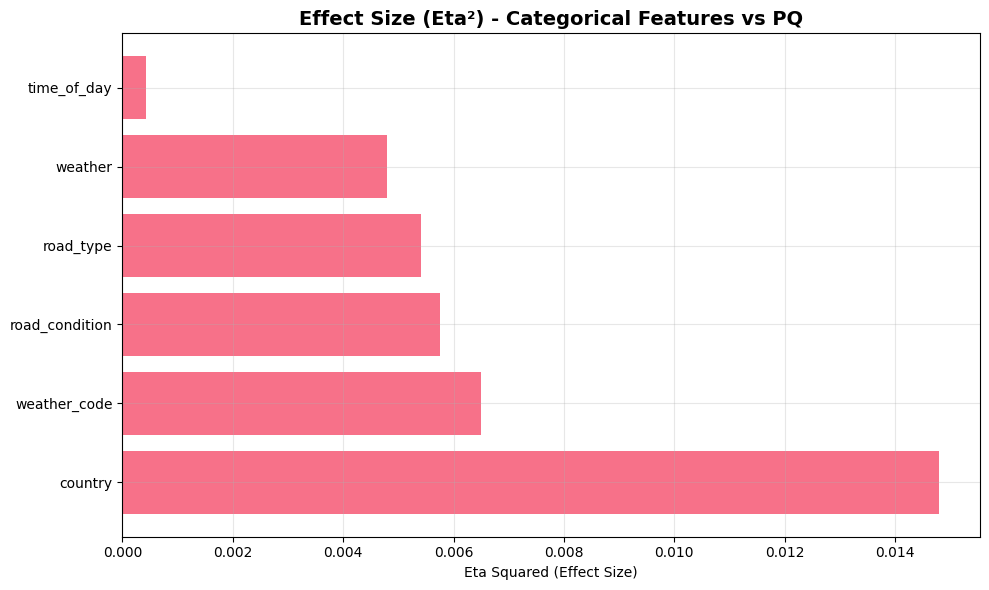

In [18]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_pq_corr_df['col'], categorical_pq_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs PQ', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/categorical_pq_effect_size.png")
plt.show()

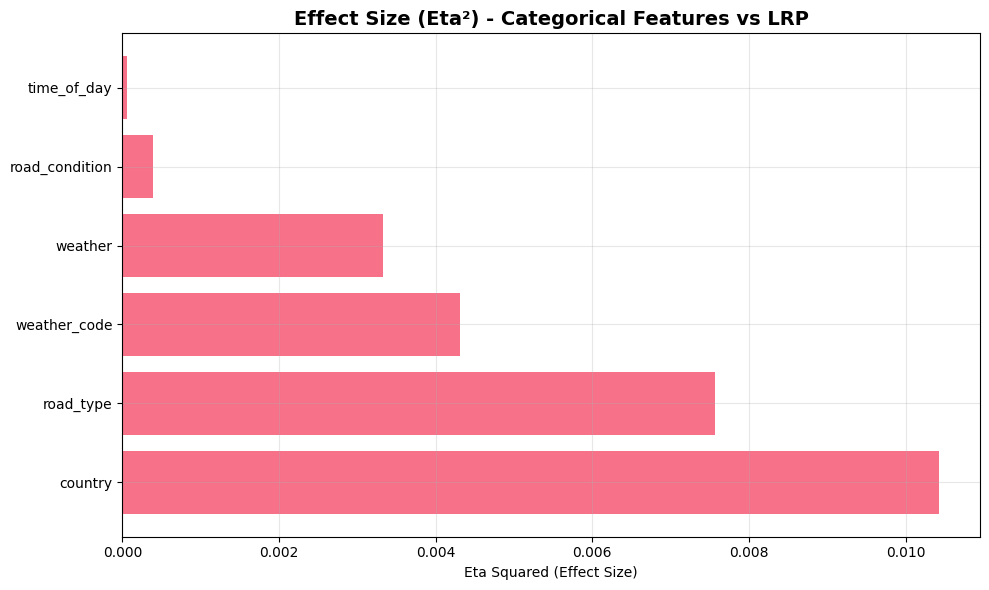

In [19]:
plt.figure(figsize=(10, 6))
plt.barh(categorical_lrp_corr_df['col'], categorical_lrp_corr_df['Eta_Squared'])
plt.title('Effect Size (Eta²) - Categorical Features vs LRP', fontsize=14, fontweight='bold')
plt.xlabel('Eta Squared (Effect Size)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/categorical_lrp_effect_size.png")
plt.show()

## Numerical Var

Plots relationship between variables and IoU using both Pearson and Spearman correlation. 

In [20]:
def compute_num_correlations(data, numeric_columns, target_column='iou'):
    numeric_correlations = []

    for col in numeric_columns:
        if col == "coords":
            continue
        pearson_corr, pearson_p = pearsonr(data[col], data[target_column])
        spearman_corr, spearman_p = spearmanr(data[col], data[target_column])
        
        numeric_correlations.append({
            'col': col,
            'Pearson_Corr': pearson_corr,
            'Spearman_Corr': spearman_corr,
        })

    numeric_corr_df = pd.DataFrame(numeric_correlations)
    numeric_corr_df = numeric_corr_df.sort_values('Pearson_Corr', key=abs, ascending=False)
    return numeric_corr_df

In [21]:
numeric_corr_df_iou = compute_num_correlations(data, numeric_columns, target_column='iou')
numeric_corr_df_pq = compute_num_correlations(data, numeric_columns, target_column='pq')
numeric_corr_df_lrp = compute_num_correlations(data, numeric_columns, target_column='lrp')


<Figure size 640x480 with 0 Axes>

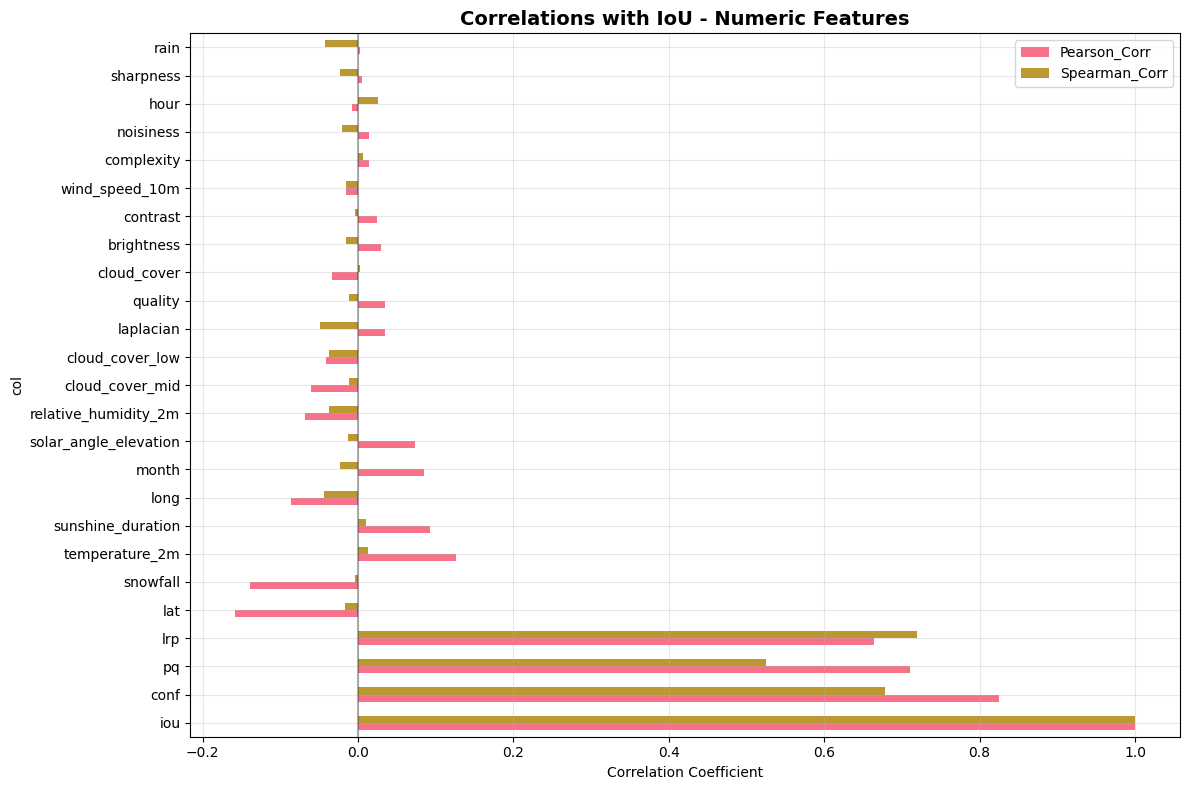

In [22]:
plt.figure()
correlations_plot = numeric_corr_df_iou.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with IoU - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/numeric_iou_correlations.png")
plt.show()

<Figure size 640x480 with 0 Axes>

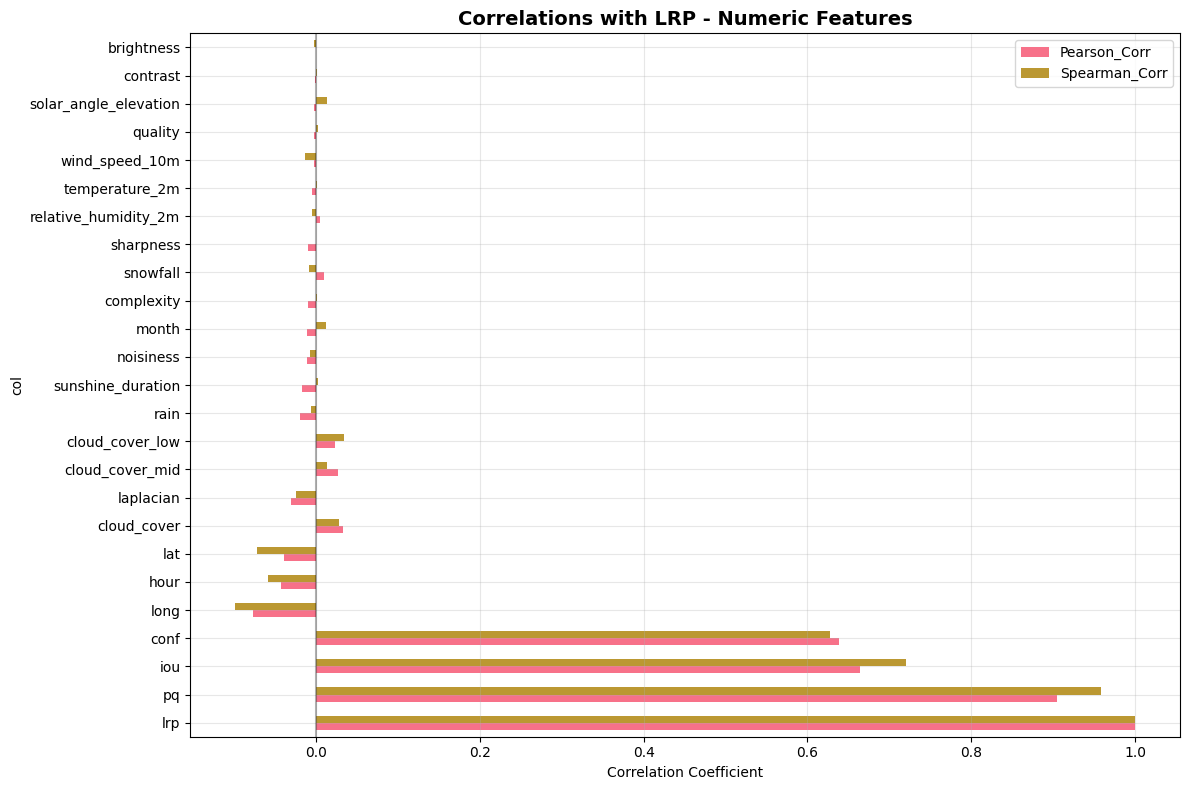

In [23]:
plt.figure()
correlations_plot = numeric_corr_df_lrp.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with LRP - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/numeric_lrp_correlations.png")
plt.show()

<Figure size 640x480 with 0 Axes>

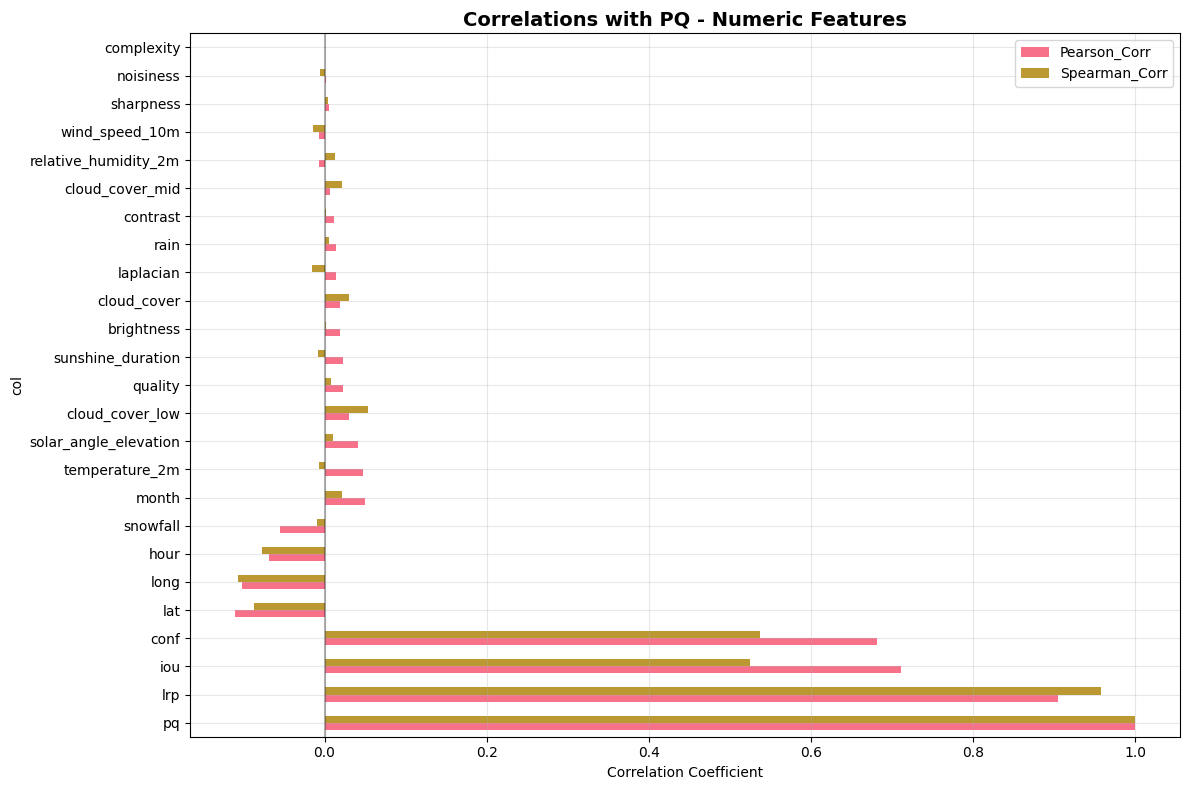

In [24]:
plt.figure()
correlations_plot = numeric_corr_df_pq.set_index('col')[['Pearson_Corr', 'Spearman_Corr']]
correlations_plot.plot(kind='barh', figsize=(12, 8))
plt.title('Correlations with PQ - Numeric Features', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/numeric_pq_correlations.png")
plt.show()

# Characteristic Curves

Success rate (IoU) vs Relevant or Irrelevant feature. Try this for both. Are of curve = capability. Also Black dashed line is added to show the linear regression for the black points (pass/fail). 

The conformances (Spearman correlations against monotonic sequence) are 0.80, 0.60, 1.00 and −0.50, respectively. Dont completly understand this.

# Agent Characteristic Grids

Placing each feature as a dimension and the success rate (or other performance metric) represented in colours (or shade of grey).